# Muffin Purchase Prediction Project

In [1]:
"""
PROJECT: Muffin Purchase Prediction
BUSINESS PROBLEM: Predict if a customer will buy a muffin to optimize baking quantity
TYPE: Binary Classification (Buy or Not Buy)
SUCCESS METRIC: Accuracy, Precision, Recall (to minimize waste vs lost sales)
"""

# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_curve, auc, precision_recall_curve)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)


print("MUFFIN PURCHASE PREDICTION - DATA SCIENCE WORKFLOW")


MUFFIN PURCHASE PREDICTION - DATA SCIENCE WORKFLOW


# Data Collection & Loading

In [38]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 120  # increase size (VERY IMPORTANT)

data = {
    'customer_id': range(1, n+1),
    'time_of_day': np.random.choice(['Morning', 'Afternoon'], n),
    'weather': np.random.choice(['Sunny', 'Rainy'], n),
    'temperature_c': np.random.randint(10, 30, n),
    'coffees_bought': np.random.randint(1, 5, n),
    'minutes_waiting': np.random.randint(1, 10, n)
}

df = pd.DataFrame(data)

# 🎯 CREATE TARGET WITH LOGIC (THIS IS KEY)
df['bought_muffin'] = (
    (df['temperature_c'] < 18).astype(int) +   # cold → more likely
    (df['coffees_bought'] >= 2).astype(int) +  # more coffee → more likely
    (df['weather'] == 'Rainy').astype(int)     # rainy → more likely
)

# Convert to binary (threshold)
df['bought_muffin'] = (df['bought_muffin'] >= 2).astype(int)

print(df.head())

   customer_id time_of_day weather  temperature_c  coffees_bought  \
0            1     Morning   Rainy             16               4   
1            2   Afternoon   Sunny             10               4   
2            3     Morning   Rainy             10               4   
3            4     Morning   Sunny             29               3   
4            5     Morning   Sunny             22               3   

   minutes_waiting  bought_muffin  
0                8              1  
1                3              1  
2                7              1  
3                2              0  
4                2              0  


 # Exploratory Data Analysis (EDA)

In [39]:
print("\n🔍 3.1 Data Information:")
print("-"*30)
print(df.info())


🔍 3.1 Data Information:
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      120 non-null    int64 
 1   time_of_day      120 non-null    object
 2   weather          120 non-null    object
 3   temperature_c    120 non-null    int64 
 4   coffees_bought   120 non-null    int64 
 5   minutes_waiting  120 non-null    int64 
 6   bought_muffin    120 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 6.7+ KB
None


In [40]:
# 3.2 Statistical Summary
print("\n📈 3.2 Statistical Summary:")
print("-"*30)
print(df.describe())


📈 3.2 Statistical Summary:
------------------------------
       customer_id  temperature_c  coffees_bought  minutes_waiting  \
count   120.000000     120.000000      120.000000       120.000000   
mean     60.500000      19.000000        2.508333         4.650000   
std      34.785054       6.611678        1.144925         2.468797   
min       1.000000      10.000000        1.000000         1.000000   
25%      30.750000      13.000000        1.000000         3.000000   
50%      60.500000      18.000000        2.500000         5.000000   
75%      90.250000      25.250000        4.000000         7.000000   
max     120.000000      29.000000        4.000000         9.000000   

       bought_muffin  
count     120.000000  
mean        0.525000  
std         0.501468  
min         0.000000  
25%         0.000000  
50%         1.000000  
75%         1.000000  
max         1.000000  


In [41]:
# 3.3 Check for Missing Values
print(" 3.3 Missing Values Check:")
print("-"*30)
print(df.isnull().sum())

 3.3 Missing Values Check:
------------------------------
customer_id        0
time_of_day        0
weather            0
temperature_c      0
coffees_bought     0
minutes_waiting    0
bought_muffin      0
dtype: int64


In [42]:
print("\n🎯 3.4 Target Variable Distribution:")
muffin_counts = df['bought_muffin'].value_counts()
print(f"Bought Muffin (1): {muffin_counts[1]} customers ({muffin_counts[1]/len(df)*100:.1f}%)")
print(f"Didn't Buy (0): {muffin_counts[0]} customers ({muffin_counts[0]/len(df)*100:.1f}%)")


🎯 3.4 Target Variable Distribution:
Bought Muffin (1): 63 customers (52.5%)
Didn't Buy (0): 57 customers (47.5%)


In [43]:
muffin_counts = df['bought_muffin'].value_counts()
muffin_counts

bought_muffin
1    63
0    57
Name: count, dtype: int64

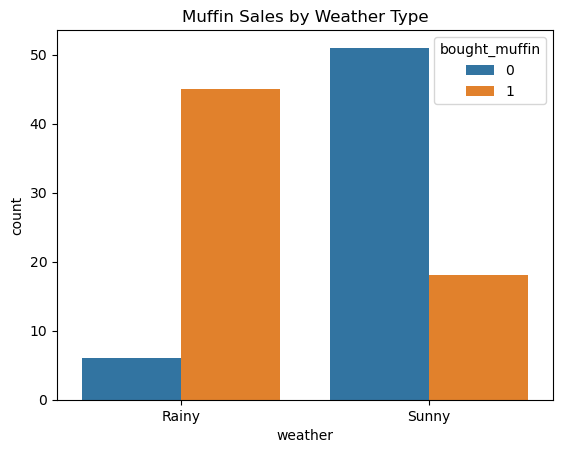

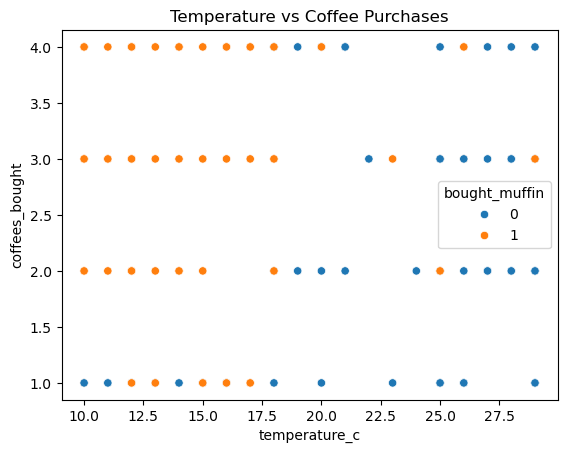

In [44]:
# 3.5 Visualizations (EDA)
import seaborn as sns
import matplotlib.pyplot as plt

# 1. How weather affects muffin purchases
sns.countplot(data=df, x='weather', hue='bought_muffin')
plt.title('Muffin Sales by Weather Type')
plt.show()

# 2. Relationship between Temperature and Coffee
sns.scatterplot(data=df, x='temperature_c', y='coffees_bought', hue='bought_muffin')
plt.title('Temperature vs Coffee Purchases')
plt.show()

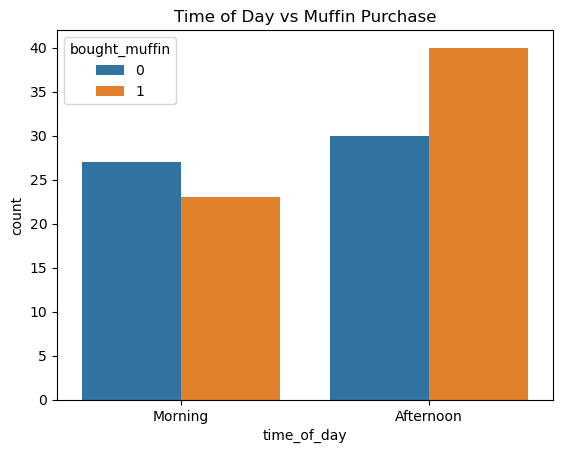

In [45]:
sns.countplot(x='time_of_day', hue='bought_muffin', data=df)
plt.title("Time of Day vs Muffin Purchase")
plt.show()

<Axes: xlabel='bought_muffin', ylabel='temperature_c'>

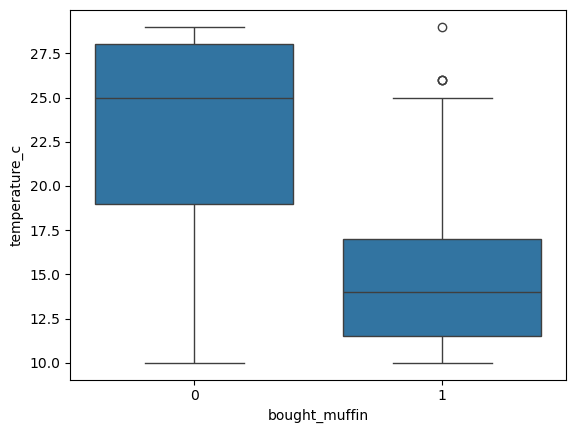

In [46]:
sns.boxplot(x='bought_muffin', y='temperature_c', data=df)

**1. People who DID NOT buy muffins (0)**

Temperature range is higher overall
Median temperature is around 25°C
Most values lie between 18°C and 27°C

👉 Meaning:
People are less likely to buy muffins in warmer temperatures

**2. People who DID buy muffins (1)**

Temperature range is lower
Median is around 11–17°C
Values spread between 15°C and 21°C

👉 Meaning:
People are more likely to buy muffins in cooler temperatures

In [47]:
print("\n\n🔧 STEP 3: DATA PREPROCESSING")
print("="*40)

# Create a copy for preprocessing
df_processed = df.copy()

# 4.1 Handle Categorical Variables
print("\n🔄 4.1 Encoding Categorical Variables:")
print("-"*30)

# Initialize label encoders
le_time = LabelEncoder()
le_weather = LabelEncoder()

# Encode categorical features
df_processed['time_encoded'] = le_time.fit_transform(df_processed['time_of_day'])
df_processed['weather_encoded'] = le_weather.fit_transform(df_processed['weather'])

print("✅ Time of Day encoded:")
for i, category in enumerate(le_time.classes_):
    print(f"   {category} → {i}")

print("\n✅ Weather encoded:")
for i, category in enumerate(le_weather.classes_):
    print(f"   {category} → {i}")

# 4.2 Feature Engineering
print("\n🔨 4.2 Feature Engineering:")
print("-"*30)

# Create interaction features
df_processed['coffee_temp_interaction'] = df_processed['coffees_bought'] * df_processed['temperature_c']
df_processed['wait_time_coffee_ratio'] = df_processed['minutes_waiting'] / (df_processed['coffees_bought'] + 1)

print("✅ Created new features:")
print("   • coffee_temp_interaction: Coffee × Temperature")
print("   • wait_time_coffee_ratio: Waiting time per coffee")

# 4.3 Select Features for Modeling
print("\n🎯 4.3 Feature Selection:")
print("-"*30)

# Define features (X) and target (y)
feature_columns = ['time_encoded', 'weather_encoded', 'temperature_c', 
                   'coffees_bought', 'minutes_waiting', 
                   'coffee_temp_interaction', 'wait_time_coffee_ratio']

X = df_processed[feature_columns]
y = df_processed['bought_muffin']

print(f"✅ Selected {len(feature_columns)} features:")
for col in feature_columns:
    print(f"   • {col}")

# 4.4 Train-Test Split
print("\n✂️ 4.4 Train-Test Split:")
print("-"*30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"✅ Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# 4.5 Feature Scaling (Optional - not required for tree-based models)
print("\n📏 4.5 Feature Scaling:")
print("-"*30)
print("ℹ️ Note: Tree-based models (Gradient Boosting, XGBoost) don't require scaling")
print("   Keeping features as-is for better interpretability")



🔧 STEP 3: DATA PREPROCESSING

🔄 4.1 Encoding Categorical Variables:
------------------------------
✅ Time of Day encoded:
   Afternoon → 0
   Morning → 1

✅ Weather encoded:
   Rainy → 0
   Sunny → 1

🔨 4.2 Feature Engineering:
------------------------------
✅ Created new features:
   • coffee_temp_interaction: Coffee × Temperature
   • wait_time_coffee_ratio: Waiting time per coffee

🎯 4.3 Feature Selection:
------------------------------
✅ Selected 7 features:
   • time_encoded
   • weather_encoded
   • temperature_c
   • coffees_bought
   • minutes_waiting
   • coffee_temp_interaction
   • wait_time_coffee_ratio

✂️ 4.4 Train-Test Split:
------------------------------
✅ Training set: 84 samples (70.0%)
✅ Testing set: 36 samples (30.0%)

📏 4.5 Feature Scaling:
------------------------------
ℹ️ Note: Tree-based models (Gradient Boosting, XGBoost) don't require scaling
   Keeping features as-is for better interpretability


#  Model Building - Gradient Boosting

In [48]:
print("\n\n🤖 STEP 5: MODEL BUILDING - XGBOOST")
print("="*40)

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train model
model.fit(X_train, y_train)

print("✅ Model trained successfully!")



🤖 STEP 5: MODEL BUILDING - XGBOOST
✅ Model trained successfully!


In [49]:
print("\n📊 STEP 6: MODEL EVALUATION")
print("="*40)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix
print("\n📌 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\n📌 Classification Report:")
print(classification_report(y_test, y_pred))


📊 STEP 6: MODEL EVALUATION
✅ Model Accuracy: 94.44%

📌 Confusion Matrix:
[[16  1]
 [ 1 18]]

📌 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        17
           1       0.95      0.95      0.95        19

    accuracy                           0.94        36
   macro avg       0.94      0.94      0.94        36
weighted avg       0.94      0.94      0.94        36



In [50]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🔥 Feature Importance:")
print(feature_importance)


🔥 Feature Importance:
                   Feature  Importance
1          weather_encoded    0.564469
3           coffees_bought    0.207542
2            temperature_c    0.146859
5  coffee_temp_interaction    0.045753
0             time_encoded    0.015590
4          minutes_waiting    0.013495
6   wait_time_coffee_ratio    0.006293
